Fetching market data …
  Data loaded: 752 trading days | 8 assets


  MAX SHARPE PORTFOLIO
  Expected Annual Return :    50.86%
  Annual Volatility      :    24.05%
  Sharpe Ratio           :    1.906
  Beta (vs SPY)          :    1.350
  95% Daily VaR          :    -2.15%
  95% Daily CVaR         :    -3.28%

  Allocation:
    GOOGL   35.4%  ██████████████
    NVDA    24.4%  █████████
    JPM     21.3%  ████████
    GS      18.9%  ███████
    MSFT     0.0%  
    AAPL     0.0%  
    AMZN     0.0%  
    TSLA     0.0%  

  MIN VOLATILITY PORTFOLIO
  Expected Annual Return :    25.61%
  Annual Volatility      :    17.46%
  Sharpe Ratio           :    1.180
  Beta (vs SPY)          :    0.998
  95% Daily VaR          :    -1.61%
  95% Daily CVaR         :    -2.50%

  Allocation:
    JPM     40.8%  ████████████████
    MSFT    31.2%  ████████████
    AAPL    17.8%  ███████
    GOOGL   10.2%  ████
    GS       0.0%  
    AMZN     0.0%  
    TSLA     0.0%  
    NVDA     0.0%  

Running Monte

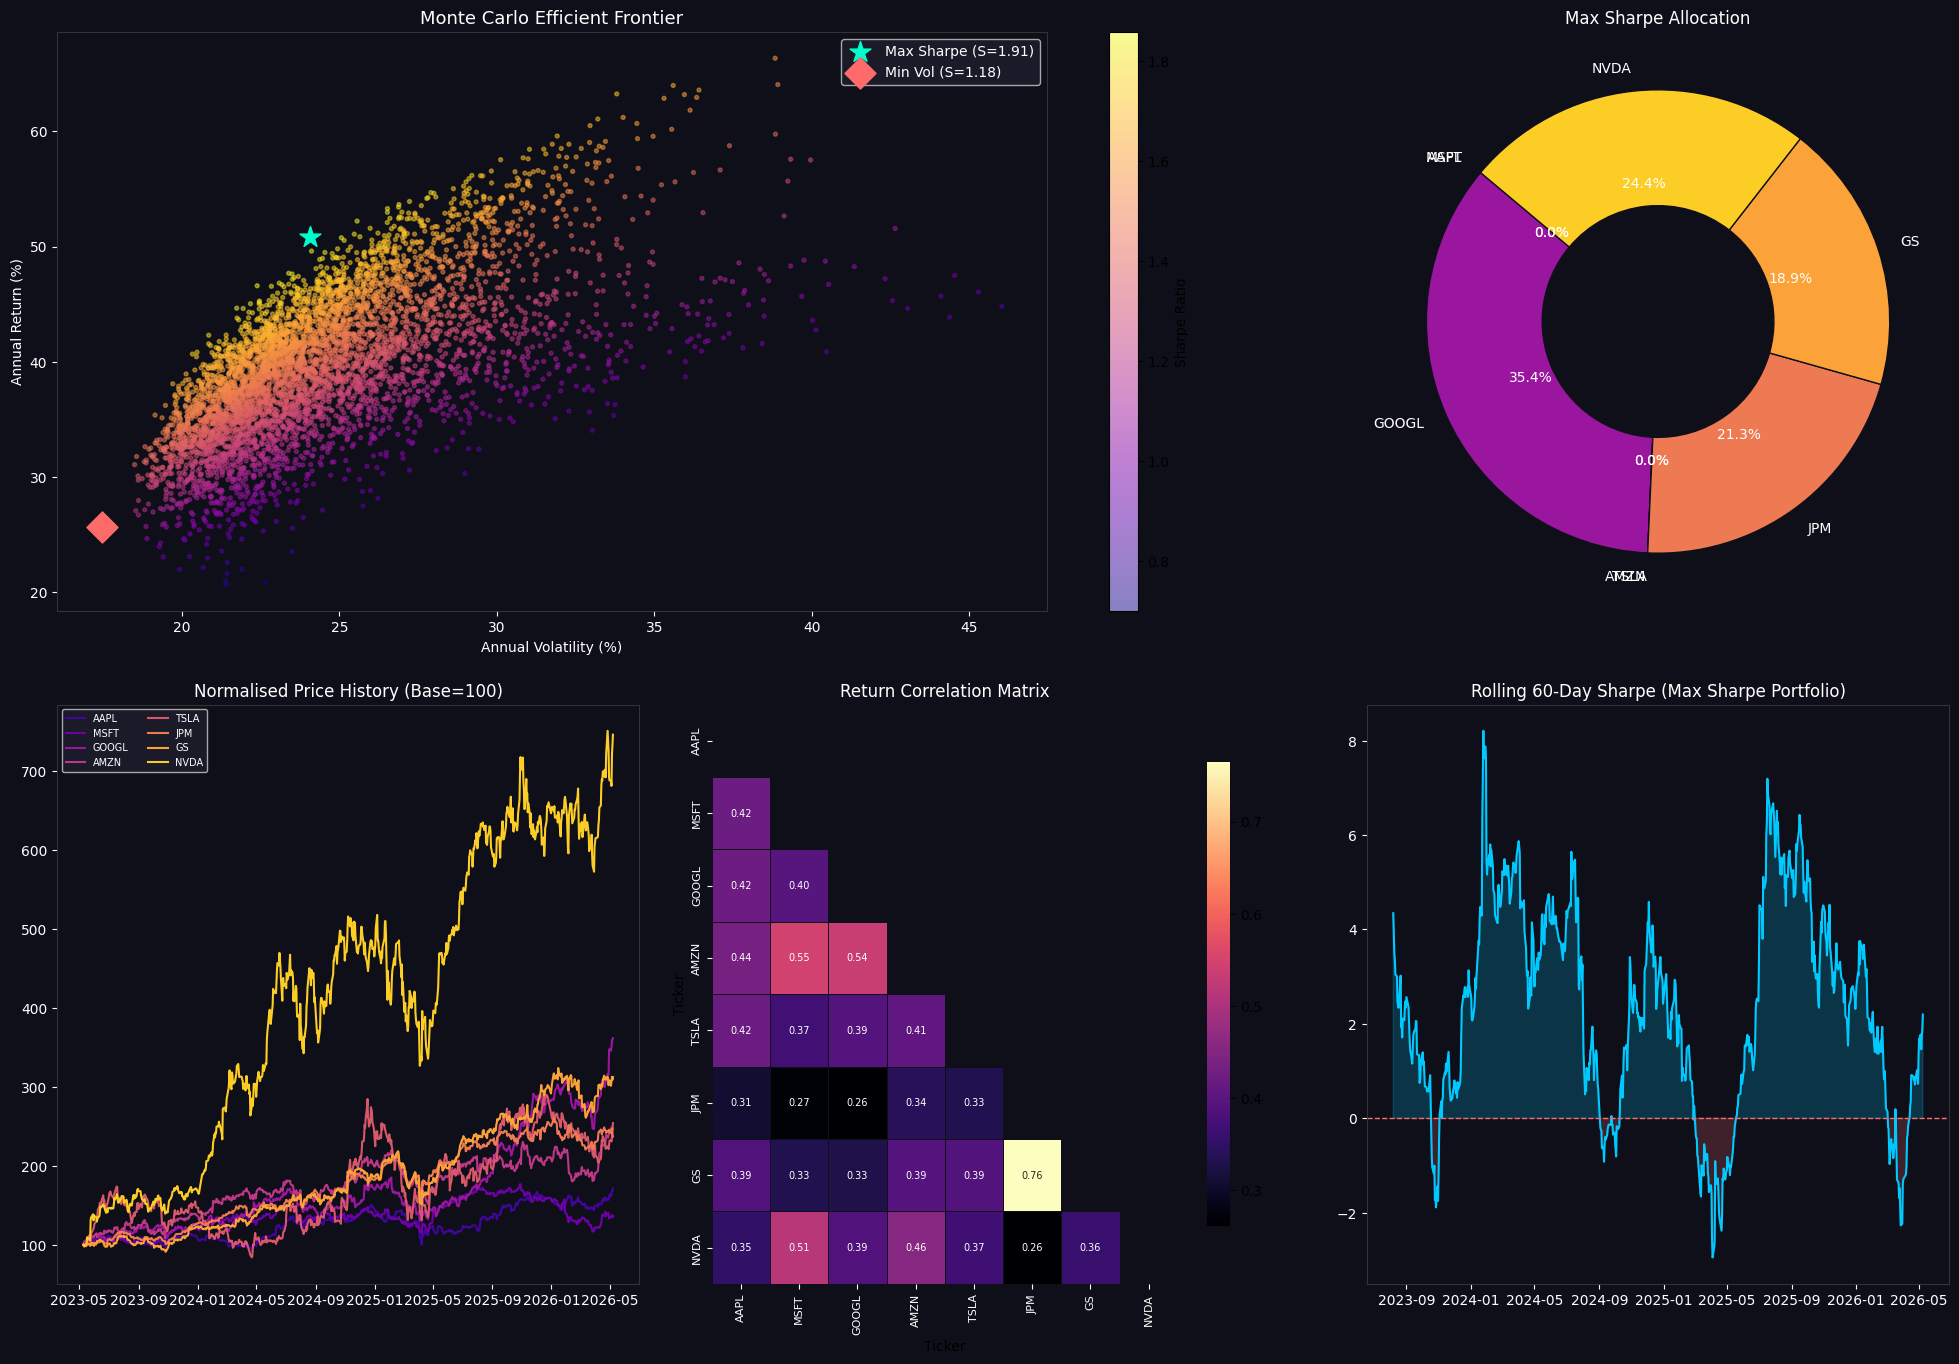


  Chart saved → portfolio_analysis.png

Done ✓


In [1]:
"""
Portfolio Risk & Return Analyzer
=================================
Analyzes a stock portfolio using real market data.
Calculates Sharpe ratio, volatility, beta, VaR, and
plots an efficient frontier.

Requirements:
    pip install yfinance pandas numpy matplotlib scipy seaborn
"""

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy.optimize import minimize
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

# ── CONFIG ─────────────────────────────────────────────────────────────────────
TICKERS   = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "JPM", "GS", "NVDA"]
BENCHMARK = "SPY"
START     = (datetime.today() - timedelta(days=3*365)).strftime("%Y-%m-%d")
END       = datetime.today().strftime("%Y-%m-%d")
RISK_FREE = 0.05        # annual risk-free rate
N_PORTFOLIOS = 5_000    # Monte Carlo simulations
# ───────────────────────────────────────────────────────────────────────────────


def fetch_data(tickers, benchmark, start, end):
    all_tickers = tickers + [benchmark]
    raw = yf.download(all_tickers, start=start, end=end, auto_adjust=True, progress=False)["Close"]
    returns = raw.pct_change().dropna()
    return raw, returns


def portfolio_stats(weights, mean_returns, cov_matrix, rf=RISK_FREE):
    ret  = np.dot(weights, mean_returns) * 252
    vol  = np.sqrt(weights @ cov_matrix @ weights) * np.sqrt(252)
    sharpe = (ret - rf) / vol
    return ret, vol, sharpe


def monte_carlo_frontier(mean_returns, cov_matrix, tickers, n=N_PORTFOLIOS):
    n_assets = len(tickers)
    results  = np.zeros((3, n))
    all_weights = []

    for i in range(n):
        w = np.random.dirichlet(np.ones(n_assets))
        all_weights.append(w)
        r, v, s = portfolio_stats(w, mean_returns, cov_matrix)
        results[0, i] = v
        results[1, i] = r
        results[2, i] = s

    return results, all_weights


def max_sharpe(mean_returns, cov_matrix, rf=RISK_FREE):
    n = len(mean_returns)
    neg_sharpe = lambda w: -portfolio_stats(w, mean_returns, cov_matrix, rf)[2]
    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    bounds = tuple((0, 1) for _ in range(n))
    init   = n * [1.0 / n]
    result = minimize(neg_sharpe, init, bounds=bounds, constraints=constraints, method="SLSQP")
    return result.x


def min_volatility(mean_returns, cov_matrix):
    n = len(mean_returns)
    min_vol = lambda w: portfolio_stats(w, mean_returns, cov_matrix)[1]
    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    bounds = tuple((0, 1) for _ in range(n))
    result = minimize(min_vol, n * [1.0 / n], bounds=bounds, constraints=constraints, method="SLSQP")
    return result.x


def value_at_risk(returns, weights, confidence=0.95):
    port_returns = returns.dot(weights)
    VaR  = np.percentile(port_returns, (1 - confidence) * 100)
    CVaR = port_returns[port_returns <= VaR].mean()
    return VaR, CVaR


def compute_beta(port_returns_series, bench_returns):
    combined = pd.concat([port_returns_series, bench_returns], axis=1).dropna()
    combined.columns = ["portfolio", "benchmark"]
    cov   = np.cov(combined["portfolio"], combined["benchmark"])
    beta  = cov[0, 1] / cov[1, 1]
    return beta


def print_report(label, weights, tickers, mean_returns, cov_matrix, returns, bench_returns):
    ret, vol, sharpe = portfolio_stats(weights, mean_returns, cov_matrix)
    VaR, CVaR = value_at_risk(returns[tickers], weights)
    port_ret  = returns[tickers].dot(weights)
    beta      = compute_beta(port_ret, bench_returns)

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Expected Annual Return : {ret*100:>8.2f}%")
    print(f"  Annual Volatility      : {vol*100:>8.2f}%")
    print(f"  Sharpe Ratio           : {sharpe:>8.3f}")
    print(f"  Beta (vs SPY)          : {beta:>8.3f}")
    print(f"  95% Daily VaR          : {VaR*100:>8.2f}%")
    print(f"  95% Daily CVaR         : {CVaR*100:>8.2f}%")
    print(f"\n  Allocation:")
    for t, w in sorted(zip(tickers, weights), key=lambda x: -x[1]):
        bar = "█" * int(w * 40)
        print(f"    {t:<6} {w*100:5.1f}%  {bar}")


def plot_all(results, all_weights, tickers, mean_returns, cov_matrix,
             ms_weights, mv_weights, prices):

    fig = plt.figure(figsize=(20, 14))
    fig.patch.set_facecolor("#0f0f1a")
    palette = "#00c9ff"

    # 1 — Efficient Frontier ───────────────────────────────────────────
    ax1 = fig.add_subplot(2, 3, (1, 2))
    sc  = ax1.scatter(results[0]*100, results[1]*100,
                      c=results[2], cmap="plasma", alpha=0.5, s=8)
    plt.colorbar(sc, ax=ax1, label="Sharpe Ratio")

    for label, w, marker, color in [
        ("Max Sharpe",  ms_weights, "*", "#00ffcc"),
        ("Min Vol",     mv_weights, "D", "#ff6b6b"),
    ]:
        r, v, s = portfolio_stats(w, mean_returns, cov_matrix)
        ax1.scatter(v*100, r*100, marker=marker, s=250, color=color,
                    zorder=5, label=f"{label} (S={s:.2f})")

    ax1.set_facecolor("#0f0f1a")
    ax1.set_xlabel("Annual Volatility (%)", color="white")
    ax1.set_ylabel("Annual Return (%)", color="white")
    ax1.set_title("Monte Carlo Efficient Frontier", color="white", fontsize=13)
    ax1.tick_params(colors="white")
    ax1.legend(facecolor="#1e1e2e", labelcolor="white")
    for spine in ax1.spines.values():
        spine.set_edgecolor("#333")

    # 2 — Allocation Donut ─────────────────────────────────────────────
    ax2 = fig.add_subplot(2, 3, 3)
    colors = cm.plasma(np.linspace(0.1, 0.9, len(tickers)))
    wedges, texts, autotexts = ax2.pie(
        ms_weights, labels=tickers, autopct="%1.1f%%",
        colors=colors, startangle=140,
        wedgeprops=dict(width=0.5, edgecolor="#0f0f1a")
    )
    for t in texts + autotexts:
        t.set_color("white")
    ax2.set_title("Max Sharpe Allocation", color="white", fontsize=12)
    ax2.set_facecolor("#0f0f1a")

    # 3 — Normalised Price History ─────────────────────────────────────
    ax3 = fig.add_subplot(2, 3, 4)
    norm = prices[tickers] / prices[tickers].iloc[0] * 100
    for col, c in zip(norm.columns, colors):
        ax3.plot(norm.index, norm[col], label=col, linewidth=1.5, color=c)
    ax3.set_facecolor("#0f0f1a")
    ax3.set_title("Normalised Price History (Base=100)", color="white", fontsize=12)
    ax3.legend(facecolor="#1e1e2e", labelcolor="white", fontsize=7, ncol=2)
    ax3.tick_params(colors="white")
    for spine in ax3.spines.values():
        spine.set_edgecolor("#333")

    # 4 — Correlation Heatmap ──────────────────────────────────────────
    ax4 = fig.add_subplot(2, 3, 5)
    ret_data = prices[tickers].pct_change().dropna()
    corr = ret_data.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax4, cmap="magma",
                annot=True, fmt=".2f", annot_kws={"size": 7},
                linewidths=0.5, linecolor="#0f0f1a",
                cbar_kws={"shrink": 0.8})
    ax4.set_facecolor("#0f0f1a")
    ax4.set_title("Return Correlation Matrix", color="white", fontsize=12)
    ax4.tick_params(colors="white", labelsize=8)

    # 5 — Rolling Sharpe ───────────────────────────────────────────────
    ax5 = fig.add_subplot(2, 3, 6)
    port_ret_series = ret_data.dot(ms_weights)
    roll_sharpe = (port_ret_series.rolling(60).mean() /
                   port_ret_series.rolling(60).std()) * np.sqrt(252)
    ax5.plot(roll_sharpe.index, roll_sharpe, color="#00c9ff", linewidth=1.5)
    ax5.axhline(0, color="#ff6b6b", linestyle="--", linewidth=1)
    ax5.fill_between(roll_sharpe.index, roll_sharpe, 0,
                     where=roll_sharpe > 0, alpha=0.2, color="#00c9ff")
    ax5.fill_between(roll_sharpe.index, roll_sharpe, 0,
                     where=roll_sharpe < 0, alpha=0.2, color="#ff6b6b")
    ax5.set_facecolor("#0f0f1a")
    ax5.set_title("Rolling 60-Day Sharpe (Max Sharpe Portfolio)", color="white", fontsize=12)
    ax5.tick_params(colors="white")
    for spine in ax5.spines.values():
        spine.set_edgecolor("#333")

    plt.tight_layout(pad=2)
    plt.savefig("portfolio_analysis.png", dpi=150, bbox_inches="tight",
                facecolor="#0f0f1a")
    plt.show()
    print("\n  Chart saved → portfolio_analysis.png")


def main():
    print("Fetching market data …")
    prices, returns = fetch_data(TICKERS, BENCHMARK, START, END)

    mean_returns = returns[TICKERS].mean()
    cov_matrix   = returns[TICKERS].cov()
    bench_returns = returns[BENCHMARK]

    print(f"  Data loaded: {len(prices)} trading days | {len(TICKERS)} assets\n")

    # Optimised portfolios
    ms_w = max_sharpe(mean_returns, cov_matrix)
    mv_w = min_volatility(mean_returns, cov_matrix)

    print_report("MAX SHARPE PORTFOLIO", ms_w, TICKERS, mean_returns, cov_matrix,
                 returns, bench_returns)
    print_report("MIN VOLATILITY PORTFOLIO", mv_w, TICKERS, mean_returns, cov_matrix,
                 returns, bench_returns)

    # Monte Carlo
    print("\nRunning Monte Carlo simulation …")
    results, all_weights = monte_carlo_frontier(mean_returns, cov_matrix, TICKERS)

    plot_all(results, all_weights, TICKERS, mean_returns, cov_matrix,
             ms_w, mv_w, prices)

    print("\nDone ✓")


if __name__ == "__main__":
    main()